# XGBoost — Predicción de Estrés

El objetivo de este notebook es analizar el modelo **XGBoost** aplicado a la predicción del nivel de estrés urbano en el sistema de transporte de pago de Nueva York.

El modelo se utiliza principalmente como problema de **regresión**, prediciendo el valor futuro del indicador de estrés (`stress_score`) para una combinación zona-hora. Además, también se entrena una versión de **clasificación binaria** para detectar situaciones de estrés elevado.

Los targets utilizados son:

| Target | Horizonte |
|---|---|
| `target_stress_t1` | +1 hora |
| `target_stress_t3` | +3 horas |
| `target_stress_t24` | +24 horas |

En este análisis se presta especial atención al horizonte **+24h**, ya que es el más relevante para la propuesta final de anticipación del estrés urbano.

Los datos proceden del dataset agregado generado en la Capa 3:

`data/aggregated/ex_stress/df_stress_zone_hour_day`

Cada fila representa una combinación de zona y franja horaria, con variables agregadas de demanda, precio, variabilidad, variables temporales y targets desplazados en el tiempo.

La división de los datos se realiza de forma **temporal estricta**, no aleatoria, con el objetivo de evitar fugas de información:

- 70% entrenamiento
- 15% validación
- 15% test

De esta forma, el modelo se evalúa sobre datos futuros respecto a los utilizados para entrenar.

## Preprocesamiento y pipeline

El pipeline de XGBoost se basa en una preparación previa de los datos en pandas antes del entrenamiento del modelo.

Las principales etapas son:

### a) Lectura de datos
Se leen los ficheros parquet particionados del dataset agregado.

### b) Preparación de targets
Se utilizan dos variables objetivo:

- `target_stress_t24`: target continuo para regresión.
- `target_is_stress_t24`: target binario para clasificación.

Las filas con valores nulos en los targets se eliminan.

### c) Split temporal
Los datos se ordenan cronológicamente y se dividen en train, validation y test.

### d) Preparación de features
Se eliminan columnas temporales auxiliares y todos los targets para evitar leakage. Las variables categóricas se codifican mediante `get_dummies`, y las columnas se alinean entre train, validation y test.

### e) Entrenamiento
Se entrenan dos modelos:

- `XGBRegressor`, para predecir el nivel continuo de estrés.
- `XGBClassifier`, para detectar situaciones de estrés elevado.

## Hiperparámetros

Los hiperparámetros utilizados en XGBoost se han definido buscando un equilibrio entre rendimiento, estabilidad y tiempo de entrenamiento.

| Parámetro | Valor | Descripción |
|---|---:|---|
| `n_estimators` | 400 | Número de árboles |
| `max_depth` | 6 | Profundidad máxima de cada árbol |
| `learning_rate` | 0.04 | Tasa de aprendizaje |
| `subsample` | 0.85 | Fracción de filas usada por árbol |
| `colsample_bytree` | 0.85 | Fracción de columnas usada por árbol |
| `tree_method` | `hist` | Método eficiente para datasets grandes |
| `random_state` | 42 | Semilla para reproducibilidad |

En el caso de clasificación, se utiliza `scale_pos_weight` para compensar el desbalanceo entre la clase normal y la clase de estrés.

## Protocolo de entrenamiento y evaluación

El protocolo seguido es el siguiente:

```text
[Train] → entrenamiento del modelo
     ↓
[Validation] → validación y seguimiento del rendimiento
     ↓
[Test] → evaluación final sobre datos futuros no vistos
```

Las métricas principales de regresión son:

- MAE
- RMSE
- R²

Para clasificación se calculan:

- Accuracy
- Precision
- Recall
- F1-score

Finalmente, una vez seleccionado el modelo, se realiza un reentrenamiento final con todos los datos disponibles (train + validation + test) para generar el artefacto utilizado en la aplicación web.


## Celda 7 — Markdown

```markdown
## A) Análisis numérico

**1. Carga del reporte del modelo**

En primer lugar, se carga el reporte generado automáticamente por el script de entrenamiento de XGBoost. Este reporte contiene las métricas principales, los targets utilizados, el número de filas, el número de variables y las rutas de los artefactos exportados.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() or (p / ".git").exists():
            return p
    return start


PROJECT_ROOT = find_project_root()

REPORT_PATH = PROJECT_ROOT / "outputs/ejercicio2/reports/boosting/xgboost_report.json"
IMPORTANCE_PATH = PROJECT_ROOT / "outputs/ejercicio2/reports/boosting/xgboost_regression_feature_importance.csv"

if not REPORT_PATH.exists():
    raise FileNotFoundError(f"No se encontró el reporte: {REPORT_PATH}")

with REPORT_PATH.open("r", encoding="utf-8") as f:
    report = json.load(f)

report.keys()

dict_keys(['model', 'task', 'dataset_dir', 'target', 'target_regression', 'target_classification', 'rmse_test', 'mae_test', 'r2_test', 'accuracy_test', 'f1_test', 'n_rows', 'n_features', 'splits', 'regression', 'classification', 'artifacts'])

In [2]:
summary = {
    "model": report.get("model"),
    "target": report.get("target") or report.get("target_regression"),
    "target_classification": report.get("target_classification"),
    "n_rows": report.get("n_rows"),
    "n_features": report.get("n_features"),
    "rmse_test": report.get("rmse_test"),
    "mae_test": report.get("mae_test"),
    "r2_test": report.get("r2_test"),
    "accuracy_test": report.get("accuracy_test"),
    "f1_test": report.get("f1_test"),
}

pd.DataFrame([summary])

,model,target,target_classification,n_rows,n_features,rmse_test,mae_test,r2_test,accuracy_test,f1_test
0,xgboost,target_stress_t24,target_is_stress_t24,6919680,40,0.828999,0.517242,0.733192,0.973146,0.426375


**2. Métricas de regresión**

El rendimiento del modelo de regresión se evalúa mediante MAE, RMSE y R² en validation y test. El RMSE se utiliza como métrica principal, ya que penaliza en mayor medida los errores grandes, algo importante en un sistema de alerta o anticipación de situaciones de estrés.

In [3]:
regression = report["regression"]

df_regression = pd.DataFrame([
    {"split": "validation", **regression["val"]},
    {"split": "test", **regression["test"]},
])

df_regression

,split,mae,rmse,r2
0,validation,0.496742,0.803712,0.732970
1,test,0.517242,0.828999,0.733192


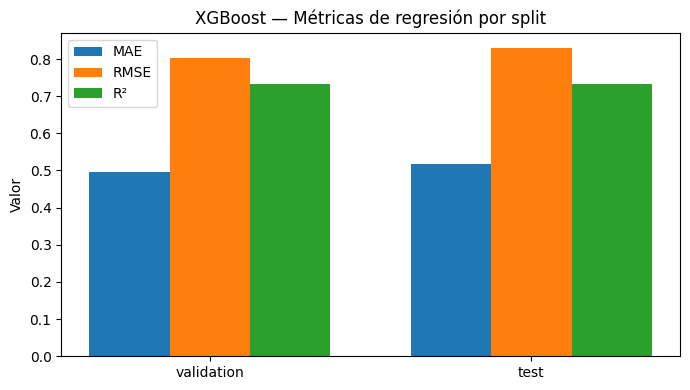

In [4]:
plt.figure(figsize=(7, 4))

x = np.arange(len(df_regression))
width = 0.25

plt.bar(x - width, df_regression["mae"], width, label="MAE")
plt.bar(x, df_regression["rmse"], width, label="RMSE")
plt.bar(x + width, df_regression["r2"], width, label="R²")

plt.xticks(x, df_regression["split"])
plt.ylabel("Valor")
plt.title("XGBoost — Métricas de regresión por split")
plt.legend()
plt.tight_layout()
plt.show()

**3. Métricas de clasificación**

Además de la regresión, XGBoost también entrena un clasificador binario para detectar situaciones de estrés. Estas métricas se interpretan como complemento, ya que el criterio principal de selección del modelo sigue siendo el RMSE del problema de regresión.

In [5]:
classification = report["classification"]

df_classification = pd.DataFrame([
    {"split": "validation", **classification["val"]},
    {"split": "test", **classification["test"]},
])

df_classification

,split,accuracy,precision,recall,f1
0,validation,0.977977,0.322300,0.669201,0.435064
1,test,0.973146,0.320266,0.637634,0.426375


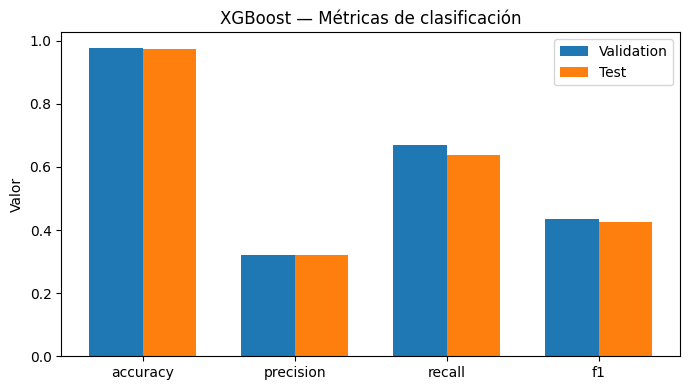

In [6]:
plt.figure(figsize=(7, 4))

metrics = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metrics))
width = 0.35

val_values = [df_classification.loc[df_classification["split"] == "validation", m].iloc[0] for m in metrics]
test_values = [df_classification.loc[df_classification["split"] == "test", m].iloc[0] for m in metrics]

plt.bar(x - width / 2, val_values, width, label="Validation")
plt.bar(x + width / 2, test_values, width, label="Test")

plt.xticks(x, metrics)
plt.ylabel("Valor")
plt.title("XGBoost — Métricas de clasificación")
plt.legend()
plt.tight_layout()
plt.show()

**4. Generalización del modelo**

Para analizar si el modelo generaliza correctamente, se compara el rendimiento entre validation y test. Una diferencia reducida entre ambos conjuntos indica que el modelo mantiene un comportamiento estable sobre datos futuros no vistos.

In [7]:
val_rmse = regression["val"]["rmse"]
test_rmse = regression["test"]["rmse"]

val_r2 = regression["val"]["r2"]
test_r2 = regression["test"]["r2"]

generalization = {
    "rmse_val": val_rmse,
    "rmse_test": test_rmse,
    "rmse_gap_test_minus_val": test_rmse - val_rmse,
    "r2_val": val_r2,
    "r2_test": test_r2,
    "r2_gap_test_minus_val": test_r2 - val_r2,
}

pd.DataFrame([generalization])

,rmse_val,rmse_test,rmse_gap_test_minus_val,r2_val,r2_test,r2_gap_test_minus_val
0,0.803712,0.828999,0.025286,0.73297,0.733192,0.000222


El gap entre validation y test permite comprobar que el modelo no presenta una degradación fuerte al pasar a datos futuros. En este caso, el rendimiento en test se mantiene cercano al observado en validation, lo que indica una capacidad de generalización adecuada.

## B) Importancia de variables

A continuación se analizan las variables más importantes del modelo de regresión. Esta información permite interpretar qué factores están contribuyendo más a la predicción del estrés urbano.

In [8]:
if not IMPORTANCE_PATH.exists():
    raise FileNotFoundError(f"No se encontró el fichero de importancias: {IMPORTANCE_PATH}")

importance_df = pd.read_csv(IMPORTANCE_PATH)
importance_df.head(15)

,feature,importance
0,n_trips,0.387712
1,z_log1p_num_trips,0.251057
2,is_stress_now,0.108109
3,stress_score,0.094927
4,lag_24h_trips,0.040016
5,roll_24h_trips,0.024731
6,roll_24h_price_variability,0.018108
7,lag_1h_trips,0.016865
8,roll_3h_trips,0.009185
9,lag_168h_trips,0.008901


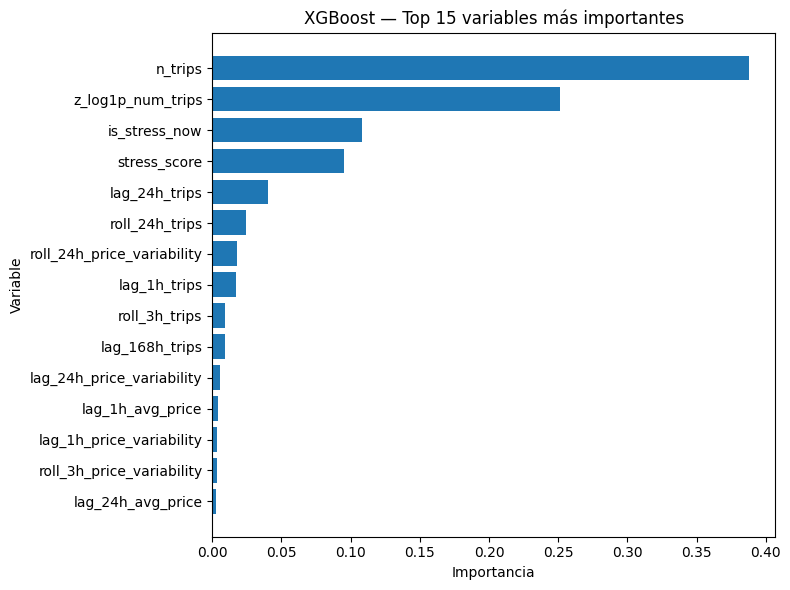

In [9]:
top_n = 15
top_importance = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title(f"XGBoost — Top {top_n} variables más importantes")
plt.tight_layout()
plt.show()

La importancia de variables permite comprobar si el modelo está aprendiendo patrones coherentes con la definición del problema. En general, se espera que variables relacionadas con el estrés actual, la demanda, la variabilidad del precio y los retardos temporales tengan un peso relevante en la predicción.

## C) Comparación validation vs test

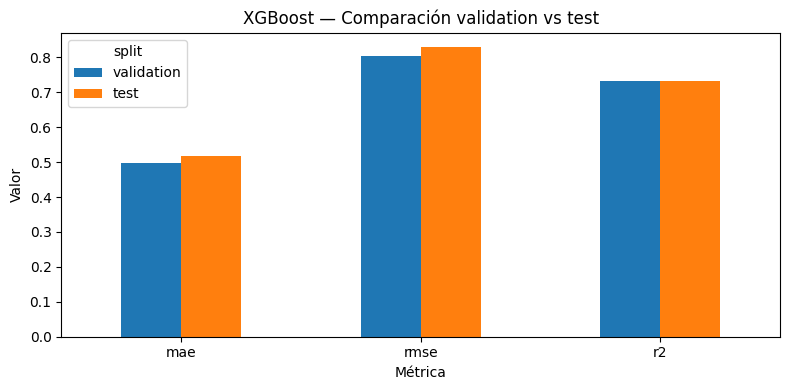

In [10]:
metrics_to_plot = ["mae", "rmse", "r2"]

plot_df = df_regression.set_index("split")[metrics_to_plot].T

ax = plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_title("XGBoost — Comparación validation vs test")
ax.set_ylabel("Valor")
ax.set_xlabel("Métrica")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La comparación entre validation y test muestra que el rendimiento del modelo se mantiene estable. Esto refuerza la validez del split temporal y sugiere que XGBoost es capaz de capturar relaciones generales del sistema, no únicamente patrones específicos del conjunto de entrenamiento.

## D) Artefactos exportados

In [11]:
artifacts = report.get("artifacts", {})
pd.DataFrame(
    [{"artifact": k, "path": v} for k, v in artifacts.items()]
)

,artifact,path
0,regression_model,C:\Grupo-PD2---Transporte-NYC\outputs\ejercici...
1,classification_model,C:\Grupo-PD2---Transporte-NYC\outputs\ejercici...
2,feature_columns,C:\Grupo-PD2---Transporte-NYC\outputs\ejercici...
3,regression_feature_importance_csv,C:\Grupo-PD2---Transporte-NYC\outputs\ejercici...
4,classification_feature_importance_csv,C:\Grupo-PD2---Transporte-NYC\outputs\ejercici...


El entrenamiento de XGBoost exporta los siguientes artefactos principales:

- modelo de regresión (`.joblib`)
- modelo de clasificación (`.joblib`)
- columnas finales utilizadas como features
- importancias de variables
- reporte con métricas y configuración

Estos artefactos permiten reutilizar el modelo posteriormente en el proceso de selección automática y en la aplicación web.

## E) Conclusiones del modelo XGBoost

El modelo XGBoost presenta un rendimiento sólido para la predicción del estrés urbano a 24 horas. En comparación con modelos más simples, reduce de forma notable el error y mantiene una buena capacidad de generalización sobre el conjunto de test.

Sus principales ventajas son:

- buen rendimiento en datos tabulares
- capacidad para capturar relaciones no lineales
- entrenamiento eficiente mediante `tree_method="hist"`
- interpretabilidad parcial mediante importancias de variables
- facilidad de exportación para despliegue

Por estos motivos, XGBoost constituye una alternativa muy competitiva dentro del conjunto de modelos evaluados para el Ejercicio 2.